### EN3160 Assignment 1 on Intensity Transformations and Neighborhood Filters

<div align="right">
<strong>Index No: 230563H</strong>
</div>

#### Q1.

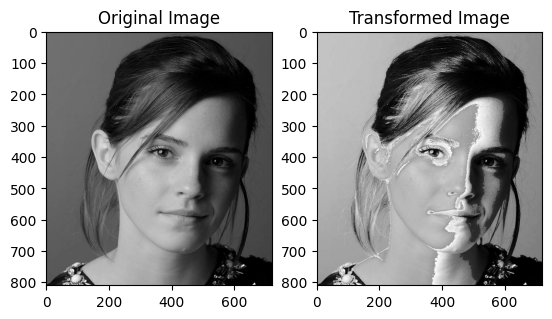

In [1]:
import cv2 
import matplotlib.pyplot as plt 
import numpy as np 

#intensity transformation fucntion
def intensity_transformation(im,breakpoints):
    x,y=zip(*breakpoints)
    t_im=np.interp(im,x,y)
    return t_im

breakpoints=[(0,0),(50,50),(50,100),(150,255),(150,150),(255,255)]

im=cv2.imread(r"C:\Users\Jaindu Samaranayaka\Documents\Semester_5\CV\intensity transformation and spatial filtering\figures\fig1b.png",cv2.IMREAD_GRAYSCALE)
t_im=intensity_transformation(im,breakpoints)
plt.subplot(1,2,1)
plt.imshow(im,cmap='gray',vmin=0,vmax=255)
plt.title("Original Image") 
plt.subplot(1,2,2)
plt.imshow(t_im,cmap='gray',vmin=0,vmax=255)
plt.title("Transformed Image") 
plt.show()


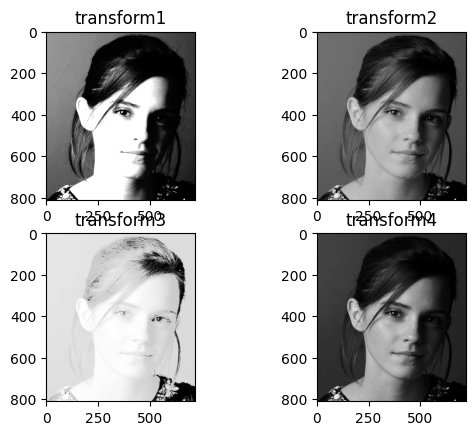

In [2]:
#experiment with different breakpoints to see the effect of intensity transformation on the image.
breakpoints1=[(0,0),(60,10),(150,255),(255,255)]
breakpoints2=[(0,0),(255,255)]
breakpoints3=[(0,0),(10,200),(200,255),(255,255)]
breakpoints4=[(0,0),(100,50),(200,200),(255,255)]

t_im1=intensity_transformation(im,breakpoints1)
t_im2=intensity_transformation(im,breakpoints2)
t_im3=intensity_transformation(im,breakpoints3)
t_im4=intensity_transformation(im,breakpoints4)

plt.subplot(2,2,1)
plt.imshow(t_im1,cmap='gray',vmin=0,vmax=255)
plt.title("transform1") 
plt.subplot(2,2,2)
plt.imshow(t_im2,cmap='gray',vmin=0,vmax=255)
plt.title("transform2")
plt.subplot(2,2,3)  
plt.imshow(t_im3,cmap='gray',vmin=0,vmax=255)
plt.title("transform3")
plt.subplot(2,2,4)
plt.imshow(t_im4,cmap='gray',vmin=0,vmax=255)
plt.title("transform4")


plt.show()



The piecewise linear transformation enhances contrast in specific intensity ranges while compressing it in others. By selecting breakpoints that steepen the slope in the mid-tones, we expand the contrast of the facial features, making them more pronounced, while compressing the very dark or bright background regions.

#### Q2.

Thresholds: 45, 124, 186


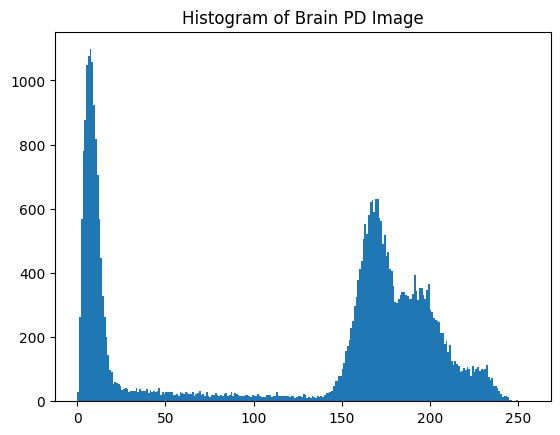

In [3]:
from skimage.filters import threshold_multiotsu

brain_img = cv2.imread(r'C:\Users\Jaindu Samaranayaka\Documents\Semester_5\CV\intensity transformation and spatial filtering\figures\fig2.png', cv2.IMREAD_GRAYSCALE)

thresholds = threshold_multiotsu(brain_img, classes=4)
t1, t2, t3 = thresholds

print(f"Thresholds: {t1}, {t2}, {t3}")
plt.hist(brain_img.ravel(), bins=256, range=[0,256])
plt.title('Histogram of Brain PD Image')
plt.show()

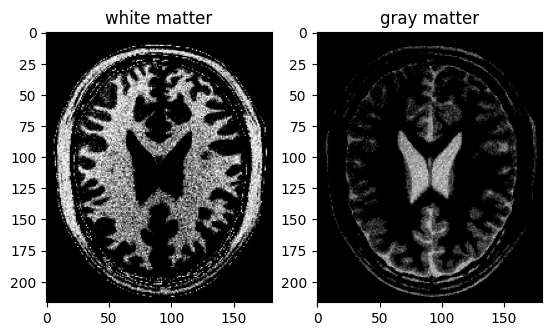

In [4]:
breakpointwhite=[(0, 0), (124, 0), (155, 255), (186, 0), (255, 0)]
breakpointgray=[(0, 0), (186, 0), (255, 255)]

t_im_white=intensity_transformation(brain_img,breakpointwhite)
t_im_gray=intensity_transformation(brain_img,breakpointgray)

plt.subplot(1,2,1)
plt.imshow(t_im_white,cmap='gray',vmin=0,vmax=255)
plt.title("white matter") 
plt.subplot(1,2,2)
plt.imshow(t_im_gray,cmap='gray',vmin=0,vmax=255)
plt.title("gray matter")
plt.show()

White and gray matter occupy distinct intensity bands in the proton density MRI. To accentuate white matter (brighter regions), the transformation steepens the slope at higher intensities. To accentuate gray matter (mid-tones), the slope is steepened in the mid-intensity range while suppressing both the lower (CSF) and higher (white matter) intensities, effectively isolating and highlighting the tissue of interest.

#### Q3.

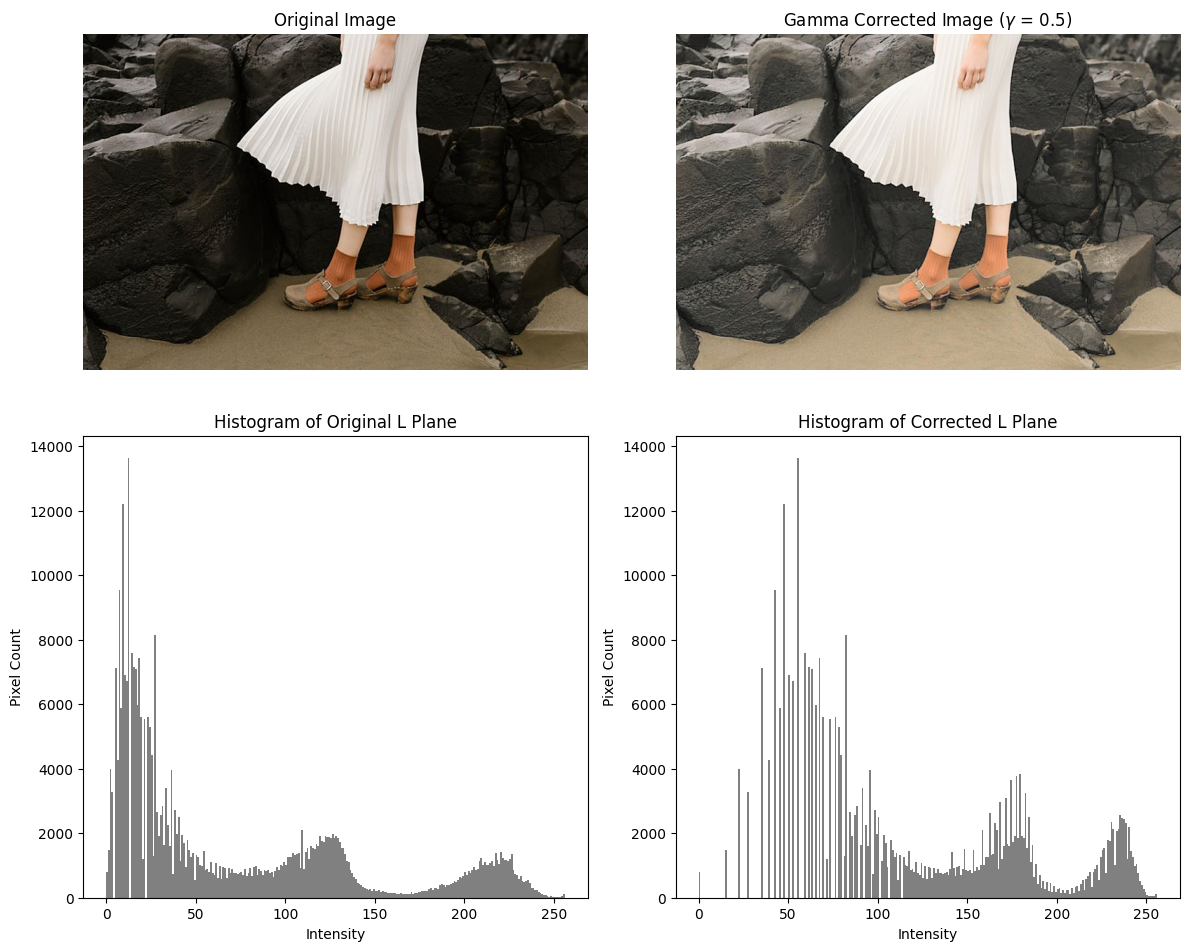

In [5]:
img_bgr = cv2.imread(r'C:\Users\Jaindu Samaranayaka\Documents\Semester_5\CV\intensity transformation and spatial filtering\figures\fig3.png')
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

L, a, b = cv2.split(img_lab)
gamma = 0.5


L_normalized = L / 255.0
L_corrected = (L_normalized ** gamma) * 255.0
L_corrected = np.clip(L_corrected, 0, 255).astype(np.uint8)
img_lab_corrected = cv2.merge((L_corrected, a, b))
img_rgb_original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_rgb_corrected = cv2.cvtColor(img_lab_corrected, cv2.COLOR_LAB2RGB)
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb_original)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_rgb_corrected)
plt.title(f'Gamma Corrected Image ($\gamma$ = {gamma})')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.hist(L.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histogram of Original L Plane')
plt.xlabel('Intensity')
plt.ylabel('Pixel Count')

plt.subplot(2, 2, 4)
plt.hist(L_corrected.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histogram of Corrected L Plane')
plt.xlabel('Intensity')
plt.ylabel('Pixel Count')

plt.tight_layout()
plt.show()

A gamma value of **$\gamma = 0.5$** was selected for the $L$ plane correction. 

* **Mathematical Effect:** Because this value is less than 1, it applies a non-linear transformation that significantly boosts lower-intensity pixel values while leaving higher-intensity values relatively unchanged.
* **Visual Outcome:** This optimally recovered the hidden textures and details in the dark foreground rocks without blowing out or overexposing the bright white skirt.

The original image suffers from underexposure in the shadows. Applying gamma correction with $\gamma < 1$ to the $L$ (Lightness) channel selectively brightens these dark regions and reveals hidden details. Operating in the $L^*a^*b^*$ space ensures that only the luminance is affected, preserving the original hue and saturation. The histograms reflect a shift toward higher lightness values.

#### Q4.

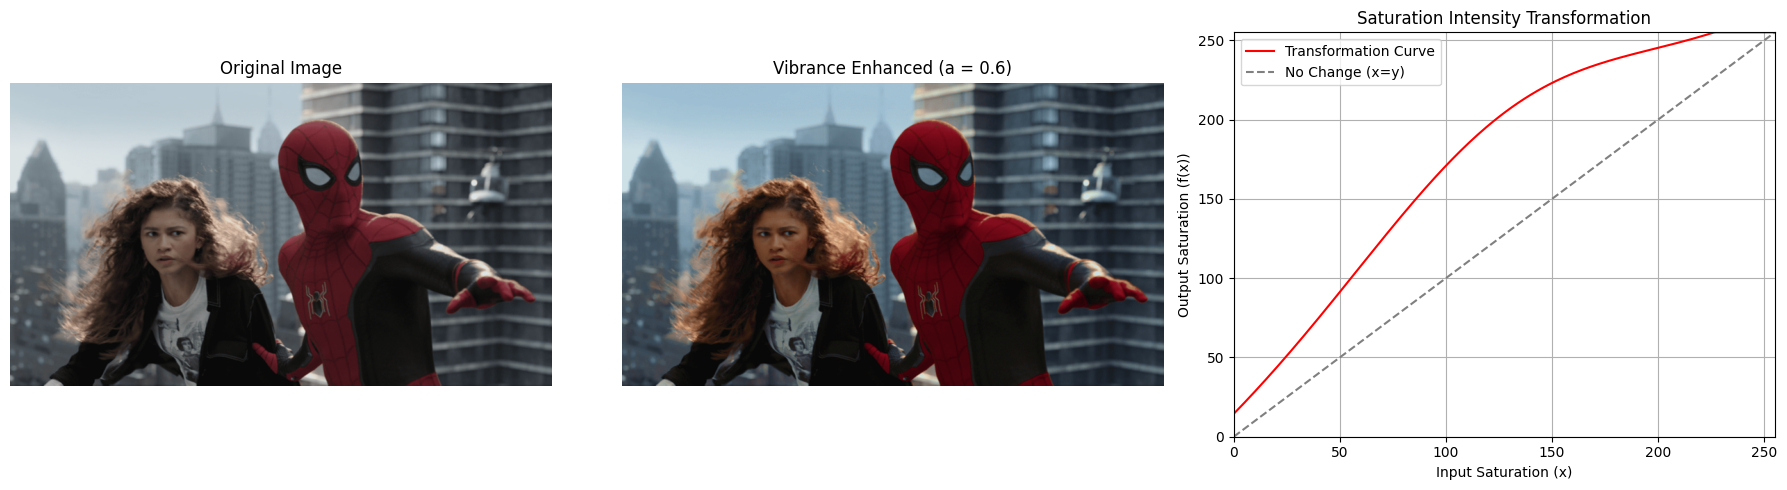

In [6]:
img_bgr = cv2.imread(r'C:\Users\Jaindu Samaranayaka\Documents\Semester_5\CV\intensity transformation and spatial filtering\figures\fig4.png')
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

h, s, v = cv2.split(img_hsv)

a = 0.6
sigma = 70

s_float = s.astype(np.float32)

boost = a * 128.0 * np.exp(-((s_float - 128.0)**2) / (2 * sigma**2))
s_enhanced = s_float + boost

s_enhanced = np.clip(s_enhanced, 0, 255).astype(np.uint8)

img_hsv_enhanced = cv2.merge((h, s_enhanced, v))

img_rgb_original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_rgb_enhanced = cv2.cvtColor(img_hsv_enhanced, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb_original)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_rgb_enhanced)
plt.title(f'Vibrance Enhanced (a = {a})')
plt.axis('off')

x_vals = np.arange(0, 256, dtype=np.float32)
y_vals = x_vals + a * 128.0 * np.exp(-((x_vals - 128.0)**2) / (2 * sigma**2))
y_vals = np.clip(y_vals, 0, 255)

plt.subplot(1, 3, 3)
plt.plot(x_vals, y_vals, color='red', label='Transformation Curve')
plt.plot([0, 255], [0, 255], color='gray', linestyle='--', label='No Change (x=y)')
plt.title('Saturation Intensity Transformation')
plt.xlabel('Input Saturation (x)')
plt.ylabel('Output Saturation (f(x))')
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Unlike standard saturation adjustments that can lead to oversaturation, this vibrance function applies a Gaussian-weighted enhancement. It selectively boosts the saturation of less-saturated pixels (centered around mid-saturation 128) while leaving already highly saturated pixels mostly unaffected. This preserves skin tones and produces a rich, vibrant, and natural-looking image.

#### Q5.

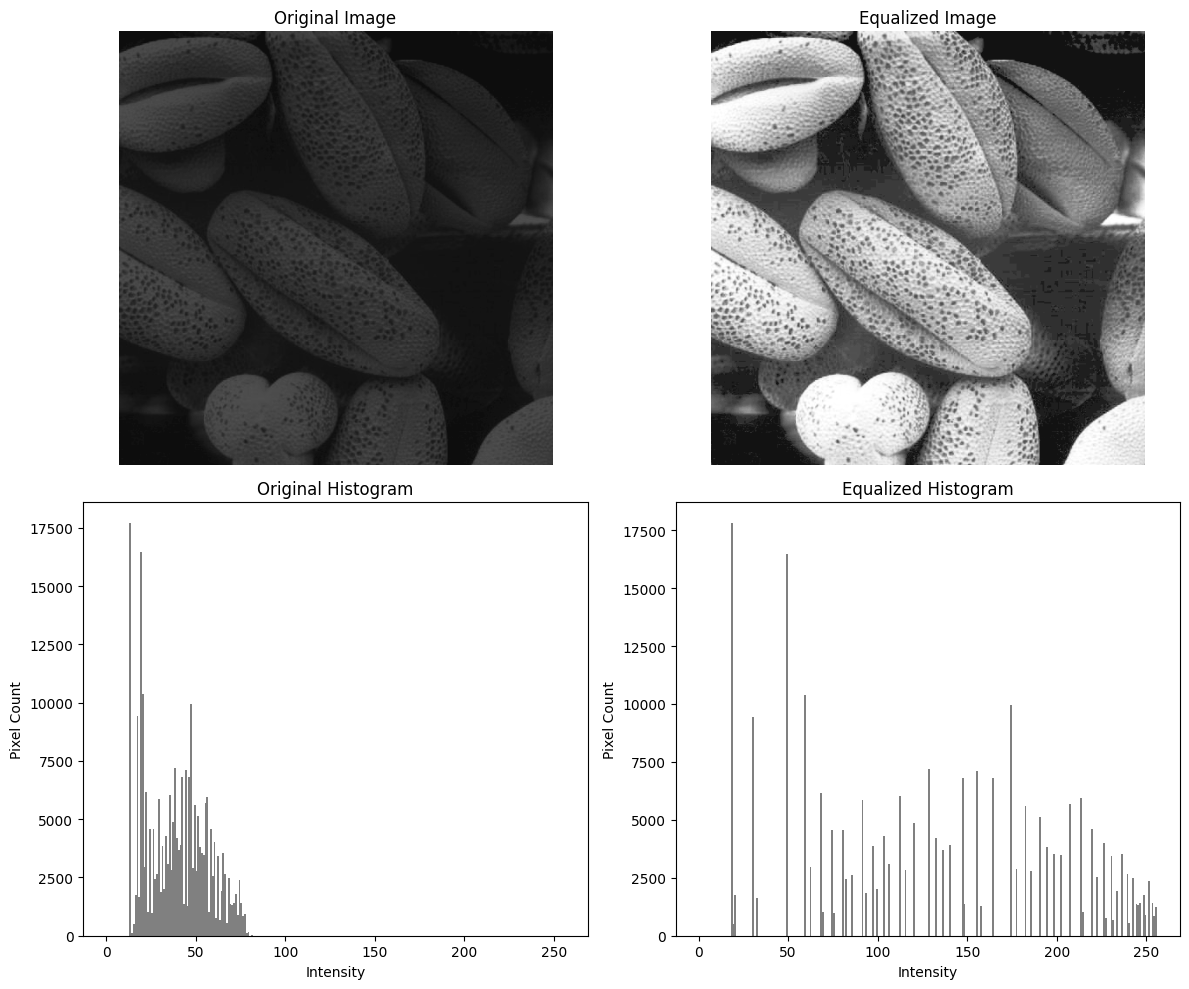

In [ ]:
def custom_histogram_equalization(img):
    histo = {i: 0 for i in range(256)}
        
    rows, cols = img.shape
    total_pixels = rows * cols
    
    for r in range(rows):
        for c in range(cols):
            pixel_val = img[r, c]
            histo[pixel_val] += 1
            
    new_pixel_values = {}
    cumulative_prob = 0.0
    
    for i in range(256):
        prob = histo[i] / total_pixels
        cumulative_prob += prob
        new_pixel_values[i] = round(cumulative_prob * 255)
        
    img_eq = np.zeros_like(img)
    
    for r in range(rows):
        for c in range(cols):
            old_val = img[r, c]
            img_eq[r, c] = new_pixel_values[old_val]
            
    return img_eq.astype(np.uint8)


img_gray = cv2.imread('C:\\Users\\Jaindu Samaranayaka\\Documents\\Semester_5\\CV\\intensity transformation and spatial filtering\\figures\\fig5.png', cv2.IMREAD_GRAYSCALE)
img_eq = custom_histogram_equalization(img_gray)

plt.figure(figsize=(12, 10))

# Original Image
plt.subplot(2, 2, 1)
plt.imshow(img_gray, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image')
plt.axis('off')

# Equalized Image
plt.subplot(2, 2, 2)
plt.imshow(img_eq, cmap='gray', vmin=0, vmax=255)
plt.title('Equalized Image')
plt.axis('off')

# Original Histogram
plt.subplot(2, 2, 3)
plt.hist(img_gray.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Original Histogram')
plt.xlabel('Intensity')
plt.ylabel('Pixel Count')

# Equalized Histogram
plt.subplot(2, 2, 4)
plt.hist(img_eq.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Equalized Histogram')
plt.xlabel('Intensity')
plt.ylabel('Pixel Count')

plt.tight_layout()
plt.show()

The original image has low contrast, as shown by its narrow, concentrated histogram. Histogram equalization automatically computes a transformation based on the cumulative distribution function (CDF), spreading the most frequent intensity values across the full 0-255 range. This dramatically improves global contrast, revealing finer textures in the pollen grains.

#### Q6.

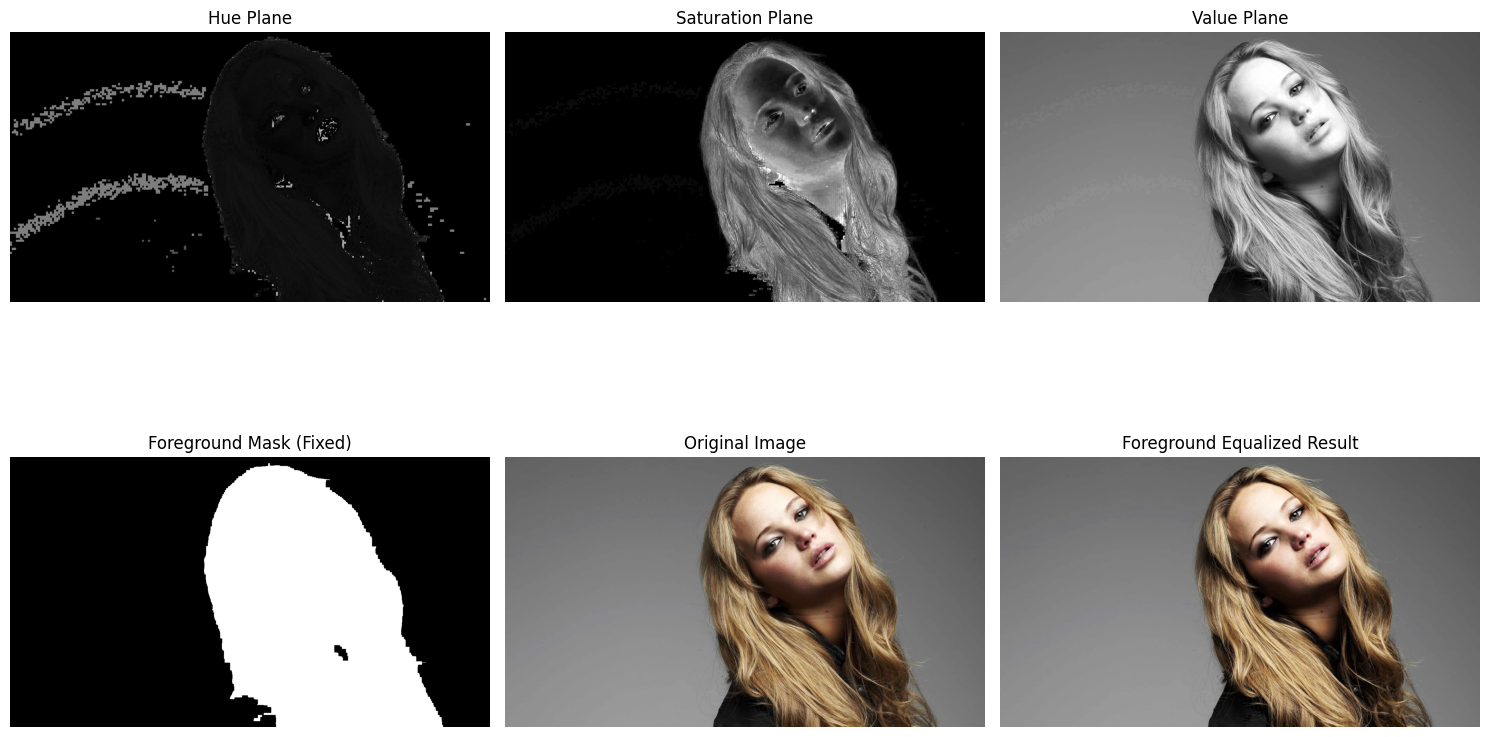

In [ ]:
# (a) Open the image, split it into hue, saturation, and values
img_bgr = cv2.imread(r'C:\Users\Jaindu Samaranayaka\Documents\Semester_5\CV\intensity transformation and spatial filtering\figures\fig6.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

# (b) Select the appropriate plane to threshold and extract the foreground mask
_, mask_initial = cv2.threshold(s, 15, 255, cv2.THRESH_BINARY)

# Apply morphological closing to fill holes (like eyes/teeth) in the mask
kernel = np.ones((7, 7), np.uint8)
mask = cv2.morphologyEx(mask_initial, cv2.MORPH_CLOSE, kernel, iterations=2)

# (c) Obtain the foreground only using cv.bitwise_and and compute the histogram
fg_v = cv2.bitwise_and(v, v, mask=mask)
hist, bins = np.histogram(fg_v[mask > 0], bins=256, range=[0, 256])

# (d) Obtain the cumulative sum of the histogram using np.cumsum
cdf = np.cumsum(hist)

MN = np.sum(hist) 
cdf_normalized = (255 / MN) * cdf
cdf_final = np.round(cdf_normalized).astype(np.uint8)

eq_fg_v = np.zeros_like(v)
eq_fg_v[mask > 0] = cdf_final[v[mask > 0]]

# (f) Extract the background and add with the histogram equalized foreground
bg_mask = cv2.bitwise_not(mask)
bg_v = cv2.bitwise_and(v, v, mask=bg_mask)

v_final = cv2.add(eq_fg_v, bg_v)

hsv_final = cv2.merge((h, s, v_final))
img_result_rgb = cv2.cvtColor(hsv_final, cv2.COLOR_HSV2RGB)

# --- Displaying the planes, mask, original image, and final result ---
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(h, cmap='gray', vmin=0, vmax=255)
plt.title('Hue Plane')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(s, cmap='gray', vmin=0, vmax=255)
plt.title('Saturation Plane')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(v, cmap='gray', vmin=0, vmax=255)
plt.title('Value Plane')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(mask, cmap='gray', vmin=0, vmax=255)
plt.title('Foreground Mask (Fixed)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(img_result_rgb)
plt.title('Foreground Equalized Result')
plt.axis('off')

plt.tight_layout()
plt.show()

Global histogram equalization can sometimes wash out backgrounds. By thresholding the image to create a binary mask, we isolate the foreground subject. Equalizing *only* this foreground and recombining it with the original background yields a naturally appealing image where the subject's features are highly pronounced without distorting the background context.

#### Q7.

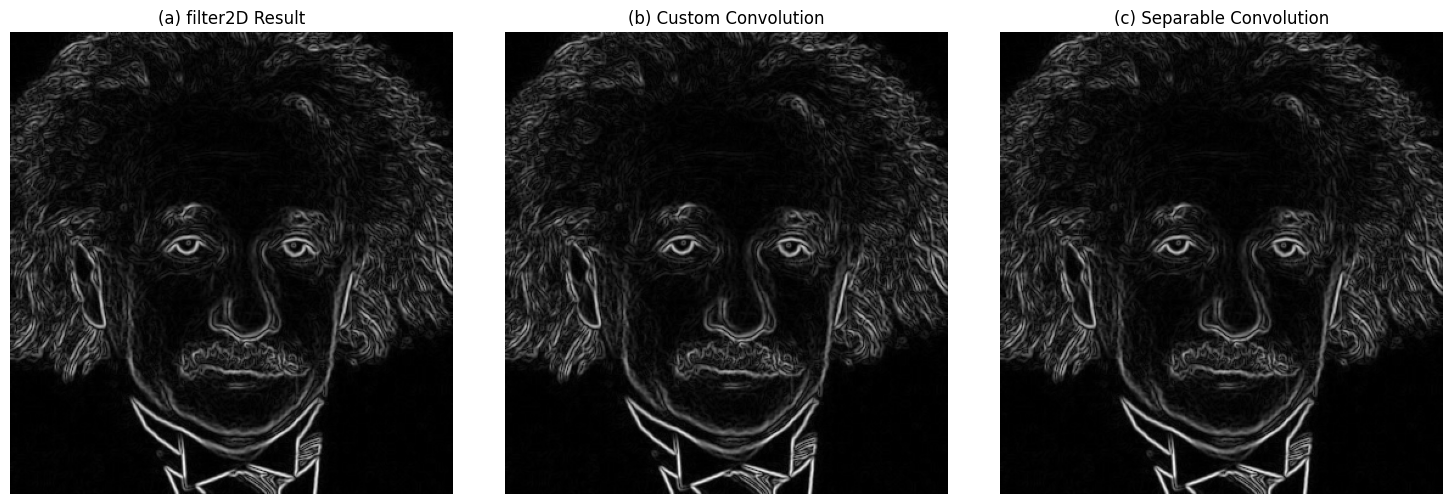

In [9]:
img = cv2.imread(r'C:\Users\Jaindu Samaranayaka\Documents\Semester_5\CV\intensity transformation and spatial filtering\figures\fig7.png', cv2.IMREAD_GRAYSCALE).astype(np.float32)

# (a) Using the existing filter2D to Sobel filter the image
sobel_x = np.array([[1, 0, -1],
                    [2, 0, -2],
                    [1, 0, -1]], dtype=np.float32)

sobel_y = np.array([[1, 2, 1],
                    [0, 0, 0],
                    [-1, -2, -1]], dtype=np.float32)

gx_a = cv2.filter2D(img, -1, sobel_x)
gy_a = cv2.filter2D(img, -1, sobel_y)
mag_a = np.sqrt(gx_a**2 + gy_a**2)

# (b) Write your own code to Sobel filter the image
def custom_convolve(image, kernel):
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2
    
    # Pad the image edges to prevent border issues
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    output = np.zeros_like(image)
    
    # Slide the kernel across the image
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            roi = padded_img[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(roi * kernel)
            
    return output

gx_b = custom_convolve(img, sobel_x)
gy_b = custom_convolve(img, sobel_y)
mag_b = np.sqrt(gx_b**2 + gy_b**2)

# (c) Using the separable property to carry out Sobel filtering
# Separated Gx vectors
col_x = np.array([[1], [2], [1]], dtype=np.float32)
row_x = np.array([[1, 0, -1]], dtype=np.float32)

# Separated Gy vectors
col_y = np.array([[1], [0], [-1]], dtype=np.float32)
row_y = np.array([[1, 2, 1]], dtype=np.float32)

# Apply 1D filters sequentially
temp_gx = custom_convolve(img, col_x)
gx_c = custom_convolve(temp_gx, row_x)

temp_gy = custom_convolve(img, col_y)
gy_c = custom_convolve(temp_gy, row_y)

mag_c = np.sqrt(gx_c**2 + gy_c**2)

# --- Normalization and Plotting ---
def normalize(mag):
    mag_norm = (mag / mag.max()) * 255
    return np.clip(mag_norm, 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(normalize(mag_a), cmap='gray')
plt.title('(a) filter2D Result')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(normalize(mag_b), cmap='gray')
plt.title('(b) Custom Convolution')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(normalize(mag_c), cmap='gray')
plt.title('(c) Separable Convolution')
plt.axis('off')

plt.tight_layout()
plt.show()

The Sobel operator approximates the image gradient to detect edges. The associative property of convolution allows the 2D Sobel kernel to be decomposed into a 1D smoothing filter and a 1D difference filter. This separability makes the computation much more efficient. The resulting gradient magnitude highlights high-frequency spatial transitions, outlining structural details.

#### Q8.

Normalized SSD (Nearest-Neighbor): 0.019940
Normalized SSD (Bilinear):         0.014966


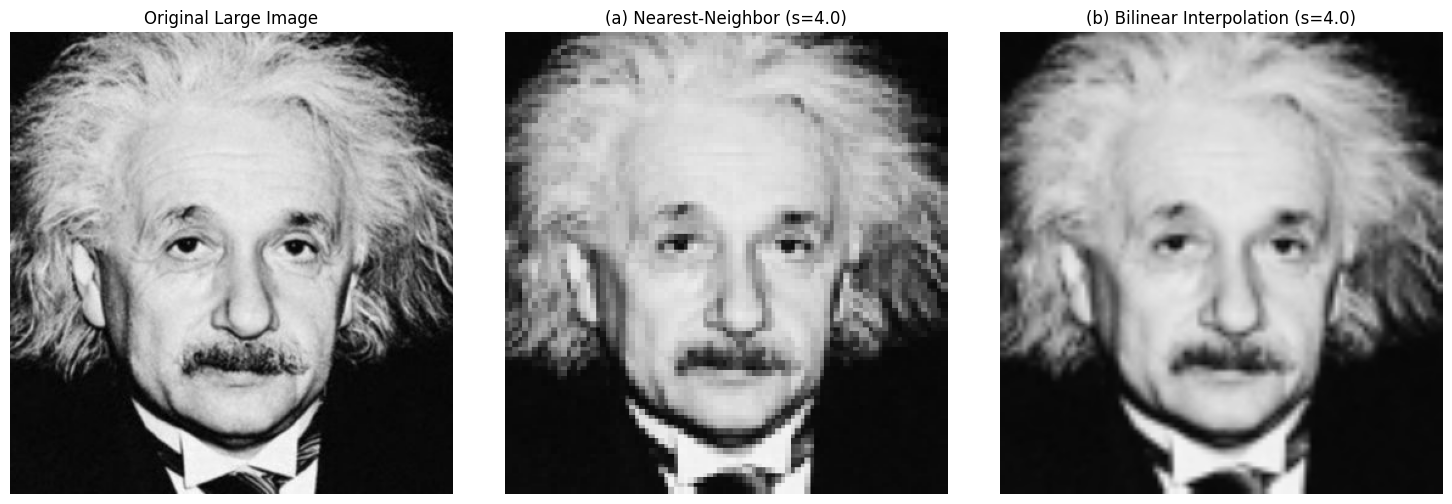

In [10]:
import os

base_dir = r"C:\Users\Jaindu Samaranayaka\Documents\Semester_5\CV\intensity transformation and spatial filtering\figures"
img_large_path = os.path.join(base_dir, "fig7.png")
img_small_path = os.path.join(base_dir, "fig7_small.png")

img_large = cv2.imread(img_large_path)

if img_large is None:
    print(f"Error: Could not load image at {img_large_path}. Please check the filename.")
else:
    # Create the zoomed-out (small) version by scaling down by a factor of 4
    h, w = img_large.shape[:2]
    img_small = cv2.resize(img_large, (w // 4, h // 4), interpolation=cv2.INTER_AREA)
    cv2.imwrite(img_small_path, img_small)

    def custom_zoom(img, s, method='nearest'):
        h, w = img.shape[:2]
        new_h, new_w = int(h * s), int(w * s)
        
        x_new, y_new = np.meshgrid(np.arange(new_w), np.arange(new_h))
        x_old = x_new / s
        y_old = y_new / s
        
        # (a) nearest-neighbor
        if method == 'nearest':
            x_nearest = np.clip(np.round(x_old).astype(int), 0, w - 1)
            y_nearest = np.clip(np.round(y_old).astype(int), 0, h - 1)
            
            if len(img.shape) == 3:
                return img[y_nearest, x_nearest, :]
            else:
                return img[y_nearest, x_nearest]
                
        # (b) bilinear interpolation
        elif method == 'bilinear':
            x_floor = np.clip(np.floor(x_old).astype(int), 0, w - 1)
            x_ceil = np.clip(np.ceil(x_old).astype(int), 0, w - 1)
            y_floor = np.clip(np.floor(y_old).astype(int), 0, h - 1)
            y_ceil = np.clip(np.ceil(y_old).astype(int), 0, h - 1)
            
            dx = x_old - x_floor
            dy = y_old - y_floor
            
            if len(img.shape) == 3:
                dx = dx[..., np.newaxis]
                dy = dy[..., np.newaxis]
                
            top_left = img[y_floor, x_floor].astype(np.float32)
            top_right = img[y_floor, x_ceil].astype(np.float32)
            bottom_left = img[y_ceil, x_floor].astype(np.float32)
            bottom_right = img[y_ceil, x_ceil].astype(np.float32)
            
            r1 = top_left * (1 - dx) + top_right * dx
            r2 = bottom_left * (1 - dx) + bottom_right * dx
            
            interpolated = r1 * (1 - dy) + r2 * dy
            return np.clip(interpolated, 0, 255).astype(np.uint8)

    def calculate_nssd(original, zoomed):
        orig_f = original.astype(np.float64)
        zoom_f = zoomed.astype(np.float64)
        min_h = min(orig_f.shape[0], zoom_f.shape[0])
        min_w = min(orig_f.shape[1], zoom_f.shape[1])
        orig_f = orig_f[:min_h, :min_w]
        zoom_f = zoom_f[:min_h, :min_w]
        
        ssd = np.sum((orig_f - zoom_f) ** 2)
        norm_factor = np.sum(orig_f ** 2)
        return ssd / norm_factor

    # Scale up the small image by a factor of 4
    s = 4.0
    zoomed_nn = custom_zoom(img_small, s, method='nearest')
    zoomed_bl = custom_zoom(img_small, s, method='bilinear')

    # Compare with the original large image
    nssd_nn = calculate_nssd(img_large, zoomed_nn)
    nssd_bl = calculate_nssd(img_large, zoomed_bl)

    print(f"Normalized SSD (Nearest-Neighbor): {nssd_nn:.6f}")
    print(f"Normalized SSD (Bilinear):         {nssd_bl:.6f}")

    # Plotting the results
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    # Convert from BGR to RGB for correct matplotlib color display
    plt.imshow(cv2.cvtColor(img_large, cv2.COLOR_BGR2RGB))
    plt.title('Original Large Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(zoomed_nn, cv2.COLOR_BGR2RGB))
    plt.title(f'(a) Nearest-Neighbor (s={s})')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(zoomed_bl, cv2.COLOR_BGR2RGB))
    plt.title(f'(b) Bilinear Interpolation (s={s})')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Nearest-neighbor interpolation duplicates the closest original pixel, which is fast but results in a blocky appearance. Bilinear interpolation computes a weighted average of the four nearest pixels, producing a smoother upscaled image. The Sum of Squared Differences (SSD) confirms that bilinear interpolation yields a lower error and higher fidelity to the original image.

### Q 9.

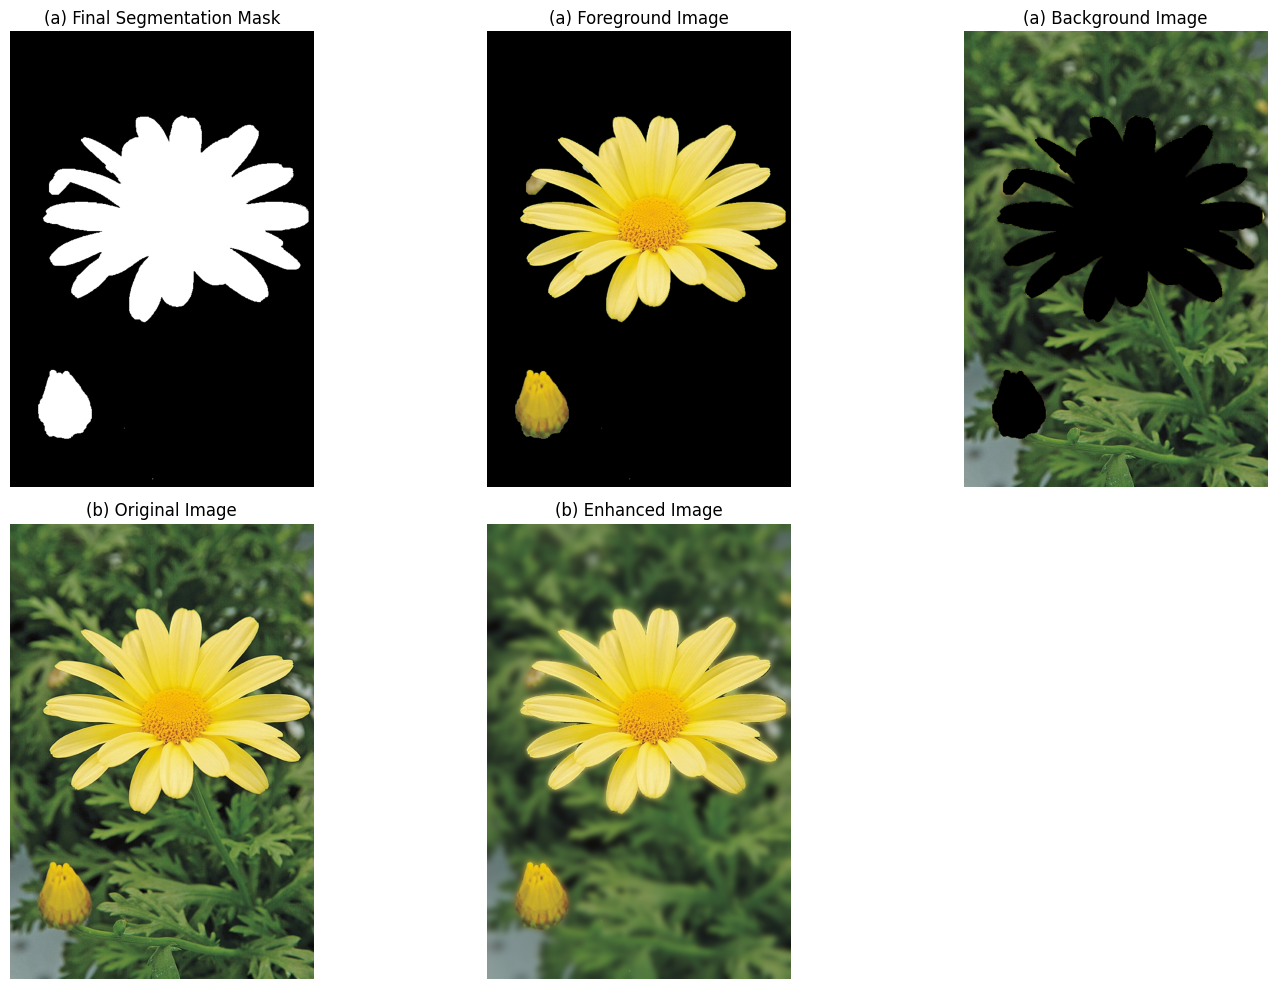

In [11]:
img_bgr = cv2.imread(r'C:\Users\Jaindu Samaranayaka\Documents\Semester_5\CV\intensity transformation and spatial filtering\figures\fig8.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# (a)
h, w = img_rgb.shape[:2]
rect = (10, 10, w - 20, h - 20)

mask = np.zeros(img_rgb.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

cv2.grabCut(img_rgb, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

binary_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

foreground = img_rgb * binary_mask[:, :, np.newaxis]
background = img_rgb * (1 - binary_mask[:, :, np.newaxis])

# (b)
blurred_base = cv2.GaussianBlur(img_rgb, (35, 35), 0)
blurred_background = blurred_base * (1 - binary_mask[:, :, np.newaxis])
enhanced_img = foreground + blurred_background

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(binary_mask, cmap='gray')
plt.title('(a) Final Segmentation Mask')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(foreground)
plt.title('(a) Foreground Image')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(background)
plt.title('(a) Background Image')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(img_rgb)
plt.title('(b) Original Image')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(enhanced_img)
plt.title('(b) Enhanced Image')
plt.axis('off')

plt.tight_layout()
plt.show()

GrabCut successfully segments the sharp foreground flower from the background. By applying a heavy blur to the background and recombining it with the sharp foreground, we simulate a shallow depth-of-field effect. **(c) Dark edge explanation:** The dark border around the flower occurs because the blur operation on the background bleeds the dark boundary pixels of the foreground into the neighboring background area.

#### Q10.

Mean Squared Error (MSE) between OpenCV and Custom Bilateral: 28.7494


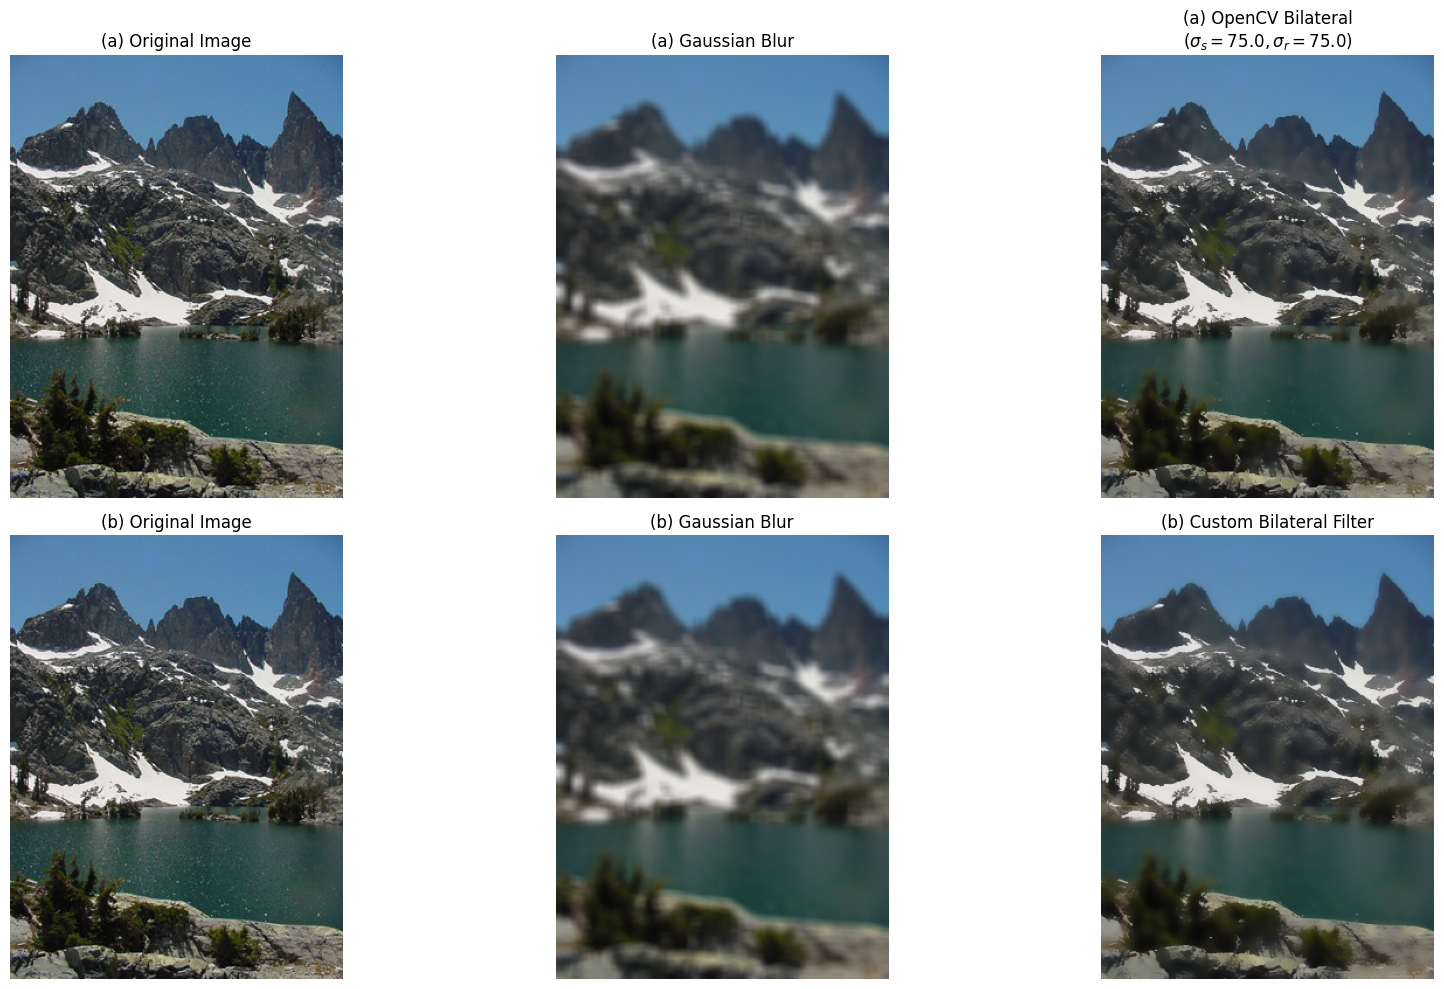

In [12]:
img_bgr = cv2.imread(r'C:\Users\Jaindu Samaranayaka\Documents\Semester_5\CV\intensity transformation and spatial filtering\figures\fig9.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

d = 9
sigma_s = 75.0
sigma_r = 75.0

# (a)
blur_gaussian = cv2.GaussianBlur(img_rgb, (d, d), sigma_s)
bilateral_cv = cv2.bilateralFilter(img_rgb, d, sigma_r, sigma_s)

# (b)
def custom_bilateral(img, d, sigma_r, sigma_s):
    img_f = img.astype(np.float32)
    h, w, c = img.shape
    pad = d // 2
    
    # Pad image to handle borders
    padded = np.pad(img_f, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    output = np.zeros_like(img_f)
    
    # Precompute the spatial Gaussian weights (distance between pixels)
    y, x = np.ogrid[-pad:pad+1, -pad:pad+1]
    spatial_w = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))
    
    for i in range(h):
        for j in range(w):
            patch = padded[i:i+d, j:j+d, :]
            center_pixel = padded[i+pad, j+pad, :]
            
            # Compute range Gaussian weights (color intensity differences)
            color_diff = patch - center_pixel
            color_dist_sq = np.sum(color_diff**2, axis=-1)
            range_w = np.exp(-color_dist_sq / (2 * sigma_r**2))
            
            # Combine spatial and range weights
            w_total = spatial_w * range_w
            
            # Apply weights to each channel and normalize
            for k in range(c):
                output[i, j, k] = np.sum(w_total * patch[:, :, k]) / np.sum(w_total)
                
    return np.clip(output, 0, 255).astype(np.uint8)

bilateral_custom = custom_bilateral(img_rgb, d, sigma_r, sigma_s)

def calculate_mse(img1, img2):
    return np.mean((img1.astype(np.float64) - img2.astype(np.float64))**2)

mse_value = calculate_mse(bilateral_cv, bilateral_custom)
print(f"Mean Squared Error (MSE) between OpenCV and Custom Bilateral: {mse_value:.4f}")

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title('(a) Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(blur_gaussian)
plt.title('(a) Gaussian Blur')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(bilateral_cv)
plt.title(f'(a) OpenCV Bilateral\n($\sigma_s={sigma_s}, \sigma_r={sigma_r}$)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(img_rgb)
plt.title('(b) Original Image')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(blur_gaussian)
plt.title('(b) Gaussian Blur')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(bilateral_custom)
plt.title('(b) Custom Bilateral Filter')
plt.axis('off')

plt.tight_layout()
plt.show()

Gaussian blurring smooths the image uniformly, which reduces noise but unfortunately blurs important structural edges. Bilateral filtering overcomes this by weighting pixels based on both spatial proximity and intensity similarity. Consequently, it heavily smooths homogenous regions while preserving sharp, abrupt intensity changes, leading to superior edge-preserving noise reduction.

**GitHub Repository:** [EN3160-A01-Intensity-Transformations-and-Neighborhood-Filtering](https://github.com/jaindusamaranayaka/EN3160-A01-Intensity-Transformations-and-Neighborhood-Filtering.git)